In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load CSV file
train_img = pd.read_csv("sign_mnist_train.csv")
test_img = pd.read_csv("sign_mnist_test.csv")
train_img.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
train_pixels = train_img.iloc[:, 1:].values
train_label = train_img.iloc[:, :1].values
test_pixels = test_img.iloc[:, 1:].values
test_label = test_img.iloc[:, :1].values

In [4]:
train_pixels[1:10]

array([[155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       [211, 211, 212, ..., 222, 229, 163],
       ...,
       [114,  42,  74, ..., 227, 228, 228],
       [169, 174, 176, ...,  74,  61,  57],
       [189, 189, 189, ..., 175, 178, 156]], shape=(9, 784))

In [5]:
train_label[1:10]

array([[ 6],
       [ 2],
       [ 2],
       [13],
       [16],
       [ 8],
       [22],
       [ 3],
       [ 3]])

In [6]:
#Normalize pixel values to [0,1]
train_pixels = train_pixels/255
test_pixels = test_pixels/255

In [7]:
train_pixels[1:10]

array([[0.60784314, 0.61568627, 0.61176471, ..., 0.40392157, 0.52941176,
        0.58431373],
       [0.73333333, 0.7372549 , 0.7372549 , ..., 0.76470588, 0.76078431,
        0.76470588],
       [0.82745098, 0.82745098, 0.83137255, ..., 0.87058824, 0.89803922,
        0.63921569],
       ...,
       [0.44705882, 0.16470588, 0.29019608, ..., 0.89019608, 0.89411765,
        0.89411765],
       [0.6627451 , 0.68235294, 0.69019608, ..., 0.29019608, 0.23921569,
        0.22352941],
       [0.74117647, 0.74117647, 0.74117647, ..., 0.68627451, 0.69803922,
        0.61176471]], shape=(9, 784))

In [8]:
# Convert to tensors
train_pixels = tf.convert_to_tensor(train_pixels, dtype=np.float32)
test_pixels = tf.convert_to_tensor(test_pixels, dtype=np.float32)
train_label = tf.convert_to_tensor(train_label, dtype=np.int32)
test_label =  tf.convert_to_tensor(test_label, dtype=np.int32)

In [9]:
type(train_pixels)

tensorflow.python.framework.ops.EagerTensor

In [10]:
train_pixels = tf.reshape(train_pixels, [-1, 28, 28, 1])
test_pixels = tf.reshape(test_pixels, [-1, 28, 28, 1])

In [11]:
train_pixels.shape

TensorShape([27455, 28, 28, 1])

In [12]:
test_label.shape

TensorShape([7172, 1])

In [13]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_pixels, train_label))
test_set = tf.data.Dataset.from_tensor_slices((test_pixels, test_label))

In [14]:
# Create validation dataset
train_set, valid_set = tf.keras.utils.split_dataset(
    train_dataset, 
    left_size=0.8, 
    shuffle=True, 
    seed=42
)

In [15]:
# Data augmentation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
data_augment = [
    RandomRotation(0.25),
    RandomZoom(0.15)
]

In [16]:
#Batching
train_set = train_set.batch(batch_size=32, drop_remainder=False)
test_set = test_set.batch(batch_size=32, drop_remainder=False)
valid_set = valid_set.batch(batch_size=32, drop_remainder=False)

In [17]:
# Baseline model building
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation, Dropout, Input
model = Sequential([
    Input(shape=(28,28,1)),
    *data_augment,
    Conv2D(filters=32, kernel_size=(3,3)),
    Activation("relu"),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3)),
    Activation("relu"),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128),
    Activation("relu"),
    Dense(256),
    Activation("relu"),
    Dense(25),
    Activation("softmax")
])

# Training model

In [18]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         6,425 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 25)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,193 (1.00 MB)

 Trainable params: 263,193 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(x=train_set, validation_data=valid_set, epochs=15)

Epoch 1/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.2442 - loss: 2.4018 - val_accuracy: 0.5003 - val_loss: 1.4108
Epoch 2/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5789 - loss: 1.2344 - val_accuracy: 0.6782 - val_loss: 0.8651
Epoch 3/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7313 - loss: 0.7735 - val_accuracy: 0.7347 - val_loss: 0.7350
Epoch 4/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8136 - loss: 0.5325 - val_accuracy: 0.8073 - val_loss: 0.5702
Epoch 5/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8612 - loss: 0.3995 - val_accuracy: 0.8483 - val_loss: 0.4324
Epoch 6/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8964 - loss: 0.3027 - val_accuracy: 0.8736 - val_loss: 0.3856
Epoch 7/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9166 - loss: 0.2463 - val_accuracy: 0.8913 - val_loss: 0.2999
Epoch 8/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9306 - loss: 0.2007 - val_acc

# Evaluating baseline model

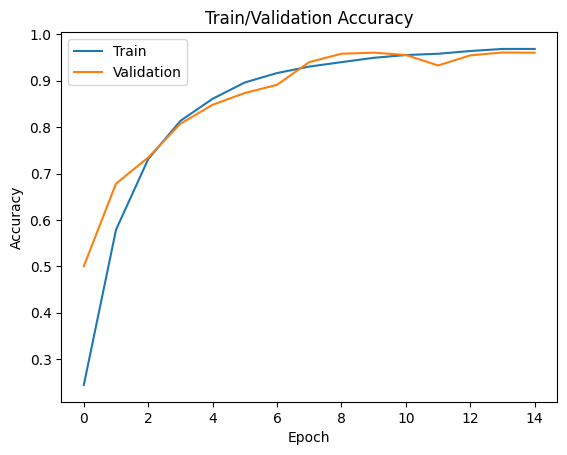

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Train/Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

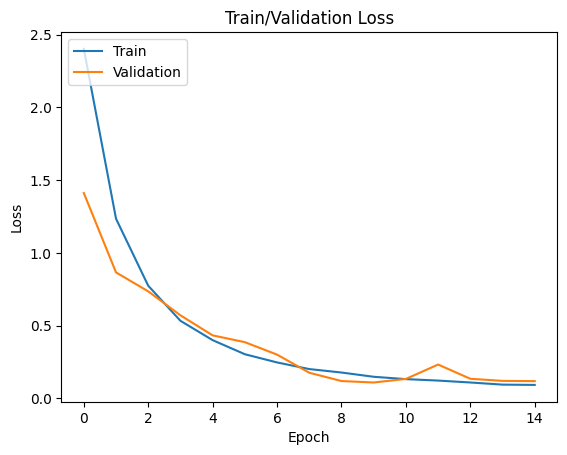

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Train/Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [23]:
model.evaluate(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8617 - loss: 0.5925


[0.5925395488739014, 0.8616843223571777]

In [24]:
prediction = model.predict(test_pixels)
prediction = np.argmax(prediction, axis=1)
prediction

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([ 6,  8, 10, ...,  2,  4,  2], shape=(7172,))

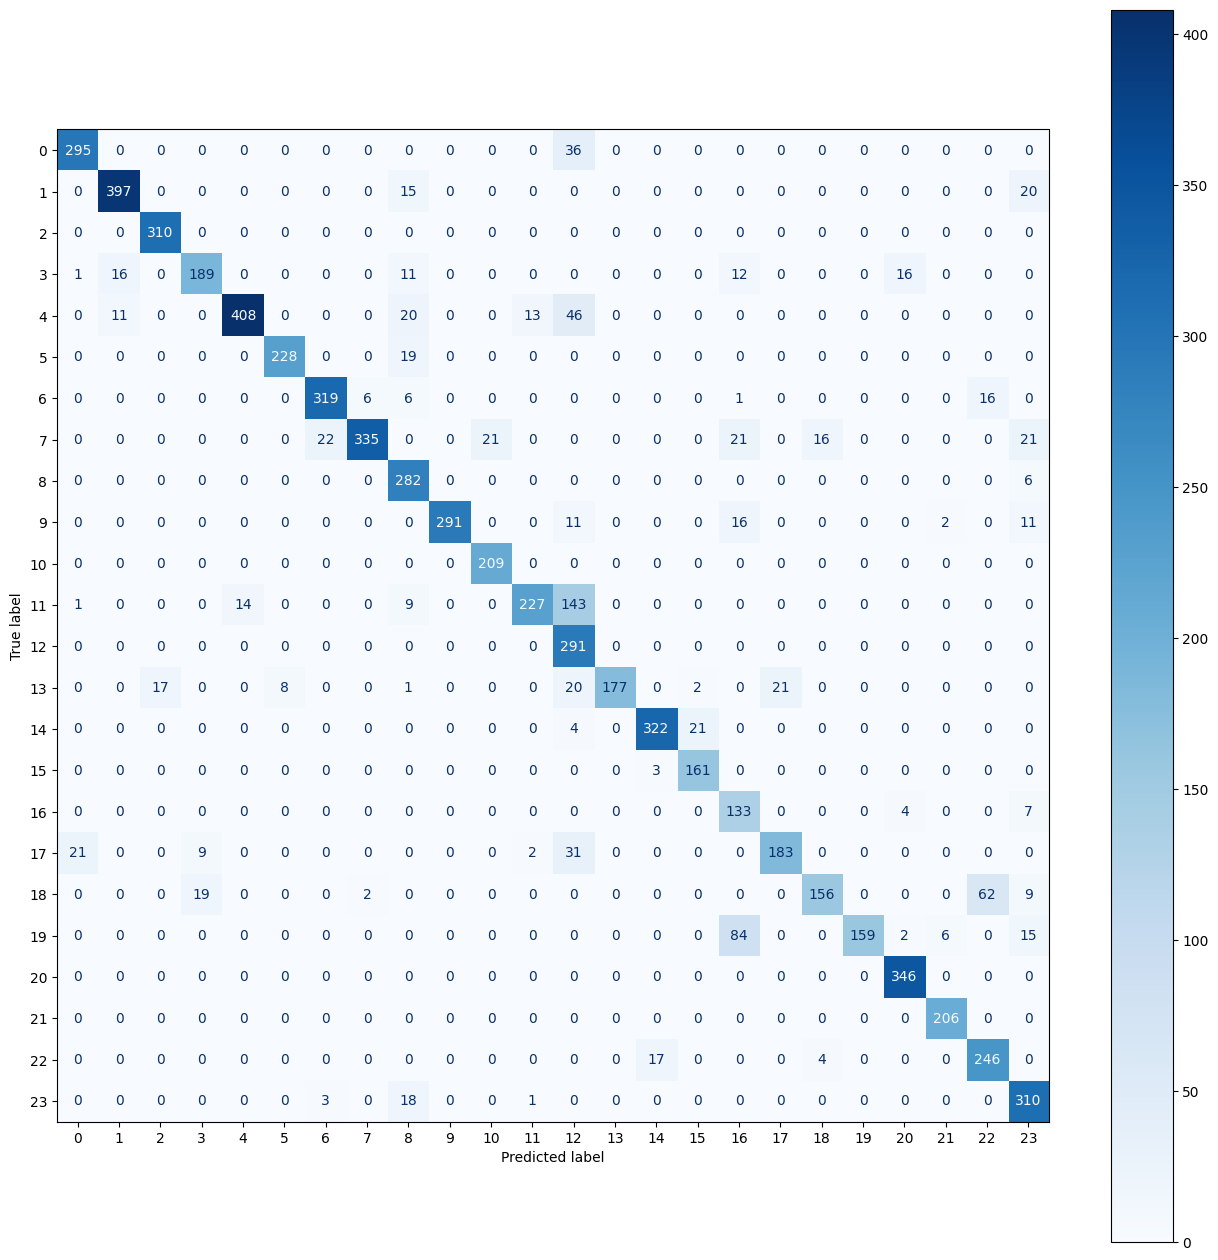

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_label, prediction)
fig, ax = plt.subplots(figsize=(16, 16)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()

In [26]:
from sklearn.metrics import classification_report
numpy_label = np.array(test_label).flatten()
numpy_prediction = np.array(prediction).flatten()

label = np.array(test_label)
label = np.unique(label)

report = classification_report(numpy_label, numpy_prediction, labels=label)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       331
           1       0.94      0.92      0.93       432
           2       0.95      1.00      0.97       310
           3       0.87      0.77      0.82       245
           4       0.97      0.82      0.89       498
           5       0.97      0.92      0.94       247
           6       0.93      0.92      0.92       348
           7       0.98      0.77      0.86       436
           8       0.74      0.98      0.84       288
          10       1.00      0.88      0.94       331
          11       0.91      1.00      0.95       209
          12       0.93      0.58      0.71       394
          13       0.50      1.00      0.67       291
          14       1.00      0.72      0.84       246
          15       0.94      0.93      0.93       347
          16       0.88      0.98      0.93       164
          17       0.50      0.92      0.65       144
          18       0.90    

## Some test image true label

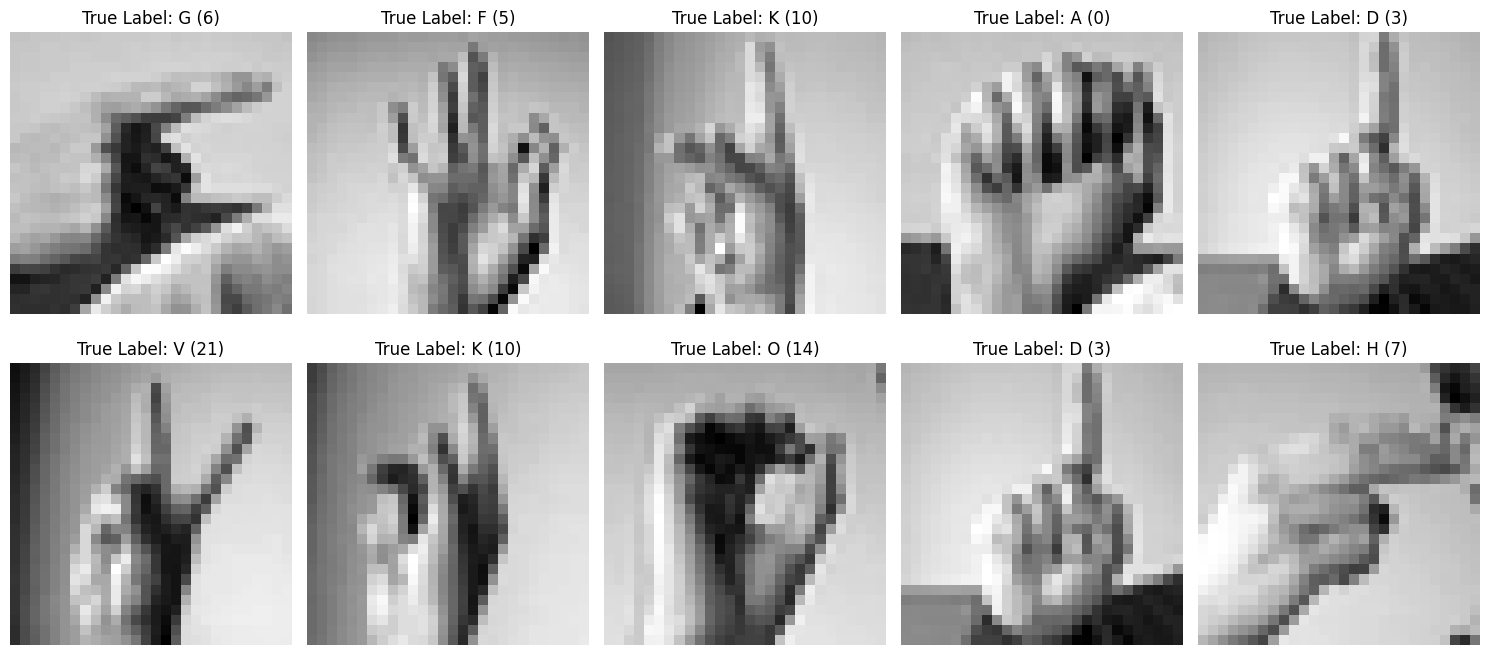

In [27]:
import string
alphabet = list(string.ascii_uppercase)

num_images = 10
fig, ax = plt.subplots(2, 5, figsize=(15, 7))
ax = ax.flatten()

for i in range(num_images):
    # .numpy() turns the tensor into a format Matplotlib understands
    ax[i].imshow(test_pixels[i].numpy(), cmap='gray') 
    
    # Extract the integer value to index the 'alphabet' list
    idx = int(test_label[i]) 
    label_char = alphabet[idx]
    
    ax[i].set_title(f"True Label: {label_char} ({idx})")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

## Enhanced CNN network

In [36]:
# Based on AlexNet, adjusted for this dataset
better_net = Sequential([
    Input(shape=(28,28,1)),
    *data_augment,
    # First layer
    Conv2D(filters=96, kernel_size=(4,4), strides=(1,1), padding='same'),
    Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    # Second layer
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    #Third layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    #Forth layer
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    #Fifth layer
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'),
    Activation('relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    Flatten(),
    # Fully connected layers
    Dense(2048),
    Activation('relu'),
    Dropout(0.5),
    Dense(1024),
    Activation('relu'),
    Dropout(0.5),
    Dense(25),
    Activation('softmax')
])


In [37]:
better_net.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [38]:
better_net.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 96)     │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 6, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 6, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │        25,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 25)             │             0 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 7,543,673 (28.78 MB)

 Trainable params: 7,543,673 (28.78 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history2 = better_net.fit(x=train_set, validation_data=valid_set, epochs=15)

Epoch 1/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.0446 - loss: 3.1854 - val_accuracy: 0.0446 - val_loss: 3.1803
Epoch 2/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.0438 - loss: 3.1796 - val_accuracy: 0.0415 - val_loss: 3.1791
Epoch 3/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.0439 - loss: 3.1784 - val_accuracy: 0.0446 - val_loss: 3.1783
Epoch 4/15
189/687 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.0399 - loss: 3.1764

KeyboardInterrupt: 